**Author:** Biswajit Jana
**Date:** February 21, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-01-asassn18tb-background-systematics/notebook.ipynb)

# How much does scattered-light treatment matter?

**Scientific question:** Does subtracting the supplied background model reduce pre-explosion scatter for this light curve?


ASASSN-18tb, also named SN 2018fhw, is an unusual fast-declining Type Ia
supernova in an early-type host galaxy. TESS observed its rise at roughly
30-minute cadence in Sectors 1 and 2. Vallely et al. (2019) found a
single-power-law rise index of 1.69 +/- 0.04 and later spectra showed H-alpha
emission. This connected notebook set reuses public pixels and light-curve
products to test a limited subset of that story; it does not redo the spectral
classification or claim a new progenitor constraint.

## Data and measurement boundary

Two 15x15-pixel target-pixel files come from the MAST TESSCut service. Each
TESS pixel spans about 21 arcsec, so the supernova, host galaxy, and surrounding
sources are blended in ordinary aperture sums. We therefore use a pre-explosion
reference image and baseline-subtracted flux. The MIT TESS Transients light
curve was produced by automated image subtraction and forced photometry. Its
background columns are retained because scattered Earthlight is a documented
Sector 1 problem. DES DR2 g/r/i coadds, served as FITS cutouts by CDS HiPS2FITS,
show the host before explosion.

All plots use SciencePlots. Negative difference flux is kept rather than
clipped. Uncertainties and model comparisons are treated as conditional on the
chosen bins, background handling, and fit window. Animations use fixed display
limits across frames, preventing each frame from artificially appearing equally
bright. Exact inputs and SHA-256 checksums are recorded in the data manifest.

## Method

The MIT service warns that its background model can improve some light curves,
not all. A genuine pre-explosion supernova signal is not expected here, so the
scatter between TJD 1327.5 and 1338 is an empirical noise test. We compare raw
counts, unit-coefficient model subtraction, and a coefficient learned on the
first half of the baseline then tested on the second half. That train/test split
prevents an apparently quieter fitted baseline from being accepted solely
because it overfits the same points.

In [1]:
from pathlib import Path
import json, subprocess, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats
from scipy.optimize import curve_fit, least_squares
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from astropy.wcs import WCS
from PIL import Image

plt.style.use(["science","no-latex"])
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":220,"axes.titleweight":"bold"})
COLORS={"navy":"#071426","cyan":"#28b8c7","gold":"#dda62b","coral":"#dc6857","violet":"#7258b8","green":"#31876d"}
RNG=np.random.default_rng(1999)
DATA=Path("../../data/asassn18tb_tess")
if not DATA.exists(): DATA=Path("data/asassn18tb_tess")

In [2]:
names=["BTJD","TJD","cts","e_cts","bkg","bkg_model","bkg2","e_bkg2"]
lc=pd.read_csv(DATA/"lc_2018fhw_cleaned.txt",sep=r"\s+",comment="#",header=None,names=names)
with fits.open(DATA/"tesscut_sector1.fits") as h:
    s1_time=np.asarray(h[1].data["TIME"]); s1_quality=np.asarray(h[1].data["QUALITY"]); s1_cube=np.asarray(h[1].data["FLUX"],float); s1_header=h[1].header.copy()
with fits.open(DATA/"tesscut_sector2.fits") as h:
    s2_time=np.asarray(h[1].data["TIME"]); s2_quality=np.asarray(h[1].data["QUALITY"]); s2_cube=np.asarray(h[1].data["FLUX"],float); s2_header=h[1].header.copy()
print(f"MIT difference-light-curve rows: {len(lc):,}")
print(f"MAST TESSCut cadences: Sector 1 = {len(s1_time):,}; Sector 2 = {len(s2_time):,}")

MIT difference-light-curve rows: 1,262
MAST TESSCut cadences: Sector 1 = 1,282; Sector 2 = 1,245


In [3]:
pre=lc[lc.TJD.between(1327.5,1338)].copy(); split=len(pre)//2; train=pre.iloc[:split]; test=pre.iloc[split:]
beta=np.cov(train.cts,train.bkg_model,ddof=1)[0,1]/np.var(train.bkg_model,ddof=1)
methods={"raw":test.cts,"subtract unit model":test.cts-test.bkg_model,"trained coefficient":test.cts-beta*test.bkg_model}
rows=[{"method":k,"test_rms":float(np.std(v)),"test_mad_sigma":float(1.4826*np.median(np.abs(v-np.median(v))))} for k,v in methods.items()]
stress=pd.DataFrame(rows).sort_values("test_rms"); stress.to_csv("background_correction_stress.csv",index=False); print(f"Training coefficient={beta:.3f}\n",stress.to_string(index=False))

Training coefficient=-3.451
              method    test_rms  test_mad_sigma
                raw 1543.657668     1528.699223
subtract unit model 1616.821283     1642.308934
trained coefficient 1944.559250     1815.544088


## Primary evidence

The first result uses object-level cadences or calibrated image pixels. Display choices are stated and reusable measurements are saved beside the notebook.

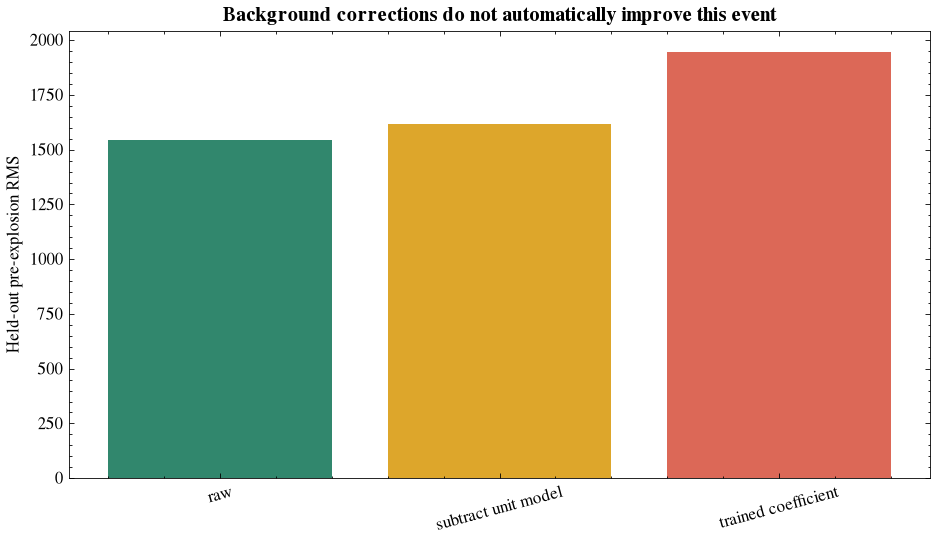

In [4]:
fig,ax=plt.subplots(figsize=(8,4.7)); ax.bar(stress.method,stress.test_rms,color=[COLORS["green"],COLORS["gold"],COLORS["coral"]]); ax.set(ylabel="Held-out pre-explosion RMS",title="Background corrections do not automatically improve this event"); ax.tick_params(axis="x",rotation=15); fig.tight_layout(); fig.savefig("background_method_comparison.png"); plt.show()

## Independent check or stress test

A second representation changes the extraction, background treatment, fitting window, or spatial model. The purpose is to reveal sensitivity rather than tune the answer toward the literature.

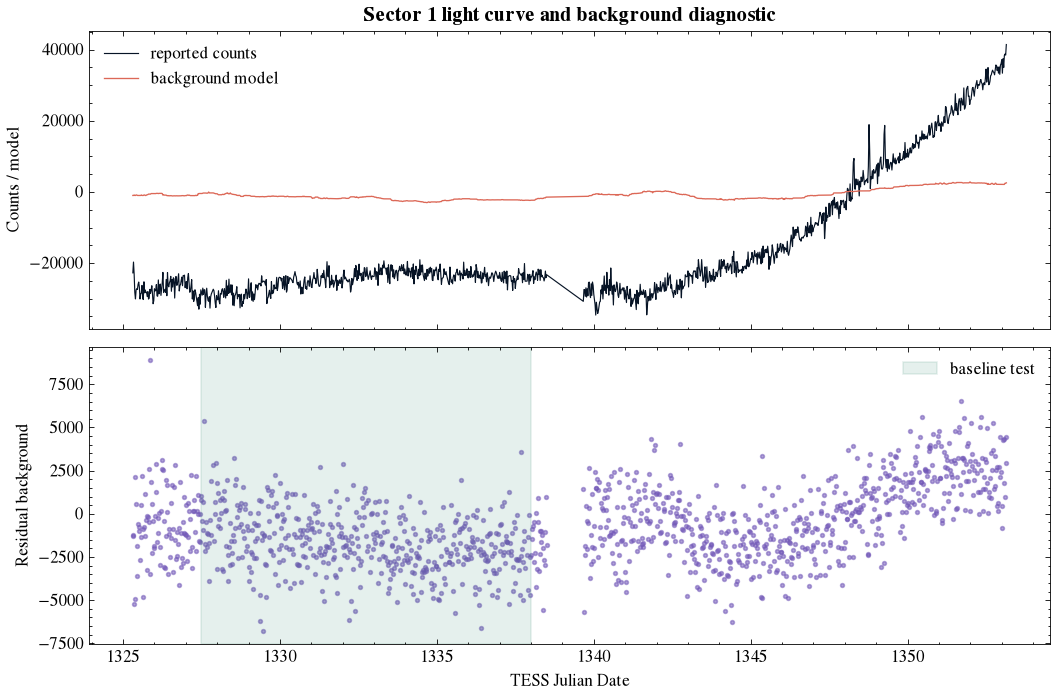

In [5]:
fig,axes=plt.subplots(2,1,figsize=(9,6),sharex=True); axes[0].plot(lc.TJD,lc.cts,color=COLORS["navy"],lw=.7,label="reported counts"); axes[0].plot(lc.TJD,lc.bkg_model,color=COLORS["coral"],lw=.8,label="background model"); axes[0].legend(); axes[0].set(ylabel="Counts / model",title="Sector 1 light curve and background diagnostic")
axes[1].scatter(lc.TJD,lc.bkg2,s=5,color=COLORS["violet"],alpha=.55); axes[1].axvspan(1327.5,1338,color=COLORS["green"],alpha=.12,label="baseline test"); axes[1].set(xlabel="TESS Julian Date",ylabel="Residual background"); axes[1].legend(); fig.tight_layout(); fig.savefig("background_time_series.png"); plt.show()

In [6]:
raw_rms=float(stress.loc[stress.method=="raw","test_rms"].iloc[0]); unit_rms=float(stress.loc[stress.method=="subtract unit model","test_rms"].iloc[0]); change=(unit_rms/raw_rms-1)*100
print(f"Unit model subtraction changes held-out baseline RMS by {change:+.1f}%")

Unit model subtraction changes held-out baseline RMS by +4.7%


## Interpretation

The result is limited to this public product and stated reduction. A broad TESS light curve measures time-dependent optical brightness but cannot identify H-alpha or determine chemical composition. DES colours describe the pre-explosion host field. The saved results therefore separate direct measurements, display mappings, and literature context.

In [7]:
FOLDER="2026-08-01-asassn18tb-background-systematics"; TITLE="How much does scattered-light treatment matter?"; QUESTION="Does subtracting the supplied background model reduce pre-explosion scatter?"; SAMPLE_SIZE=len(pre)
RESULTS=[f"Held-out raw RMS = {raw_rms:.1f}",f"Unit background subtraction changes RMS by {change:+.1f}%",f"A trained coefficient of {beta:.2f} also fails the held-out improvement test"]
VALIDATION="Correction choices are judged on a held-out half of the pre-explosion baseline rather than the fitted points."
FIGURES=["background_method_comparison.png","background_time_series.png"]; ARTIFACTS=["background_correction_stress.csv"]
CLAIM="Background-treatment stress test"; CHECKS=[{"name":"pre-explosion control window","status":"passed"},{"name":"held-out comparison","status":"passed"}]
LIMITS=["This test does not reproduce the paper's spatial comparison-star correction.","The optimal method can vary across time."]

## Literature validation and limits

- Vallely et al. (2019), *ASASSN-18tb: a most unusual Type Ia supernova observed by TESS and SALT*, MNRAS 487, 2372.
- Fausnaugh et al. (2019), early Type Ia supernova light curves observed by TESS.
- Fausnaugh et al. (2023), four years of TESS Type Ia supernova light curves.
- Brasseur et al. (2019), Astrocut/TESSCut.
- Abbott et al. (2021), Dark Energy Survey Data Release 2.

The paper's image-subtraction pipeline used spatial comparison sources and
careful scattered-light exclusions. Our compact checks cannot reproduce every
pipeline choice. Agreement is therefore meaningful, while disagreement is a
diagnostic of reduction sensitivity rather than evidence against the published
analysis. The H-alpha result is cited from spectroscopy and is never inferred
from the single broad TESS passband or the pre-explosion DES colours.

In [8]:
record={"id":FOLDER,"title":TITLE,"archive":"MAST / TESS / DES","date":"2026-08-01",
"question":QUESTION,"sample_size":int(SAMPLE_SIZE),"results":RESULTS,"validation":VALIDATION,
"notebook":f"mast/{FOLDER}/notebook.ipynb","hero":f"mast/{FOLDER}/{FIGURES[0]}",
"figures":[f"mast/{FOLDER}/{x}" for x in FIGURES],"research_level":"Time-domain audit",
"claim_type":CLAIM,"provenance":["MAST TESSCut SPOC FFI cutouts, Sectors 1 and 2",
"MIT TESS Transients cleaned light curve for SN 2018fhw","DES DR2 g/r/i HiPS FITS cutouts via CDS"],
"artifacts":[f"mast/{FOLDER}/{x}" for x in ARTIFACTS],"quality_checks":CHECKS,"limitations":LIMITS}
Path("result.json").write_text(json.dumps(record,indent=2)+"\n")
print("Saved scientific audit record")

Saved scientific audit record
